<a href="https://colab.research.google.com/github/DinaKSari/PCVK_2026_2027/blob/main/week5_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : DINA KUMALA SARI
NIM : 244107020072 | N = 72
bins   : 8
clip   : 2.0
tile   : 2
L      : 2
WAKTU : 2026-09-27 21:50:44 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 29659f83eccd900d


Text(0.5, 1.0, '244107020072 - CLAHE clip 2.0')

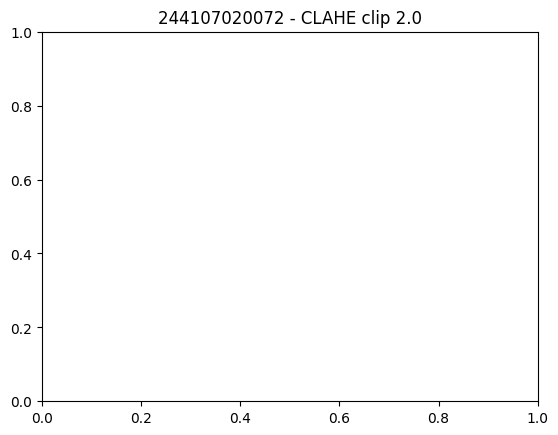

In [35]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
import matplotlib.pyplot as plt
NAMA = 'DINA KUMALA SARI'
NIM = '244107020072' # ganti dengan NIM Anda
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))

# E-1 PERCOBAAN HISTOGRAM

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

## tahap 1

<BarContainer object of 256 artists>

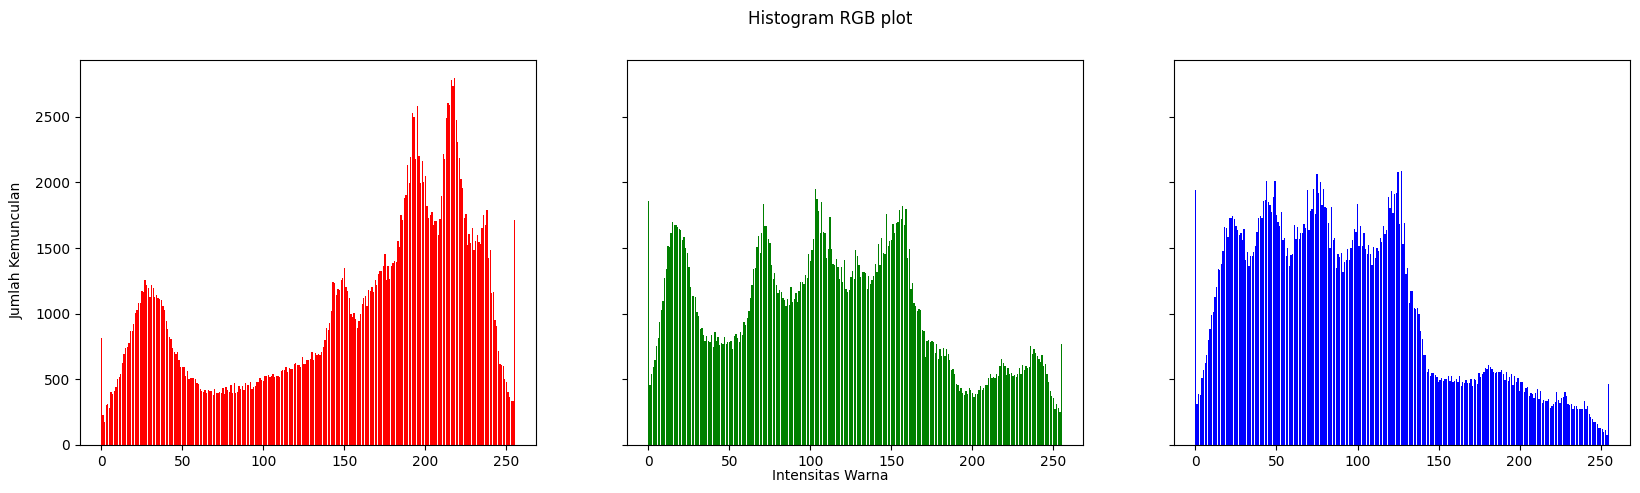

In [38]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img [y] [x] [0]] += 1
    green[img[y] [x] [1] ] += 1
    blue[img[y] [x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig. text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig. text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs [0]. bar(names, red, color='red')
axs [1].bar(names, green, color='green')
axs [2].bar(names, blue, color='blue')

## tahap 2

<BarContainer object of 256 artists>

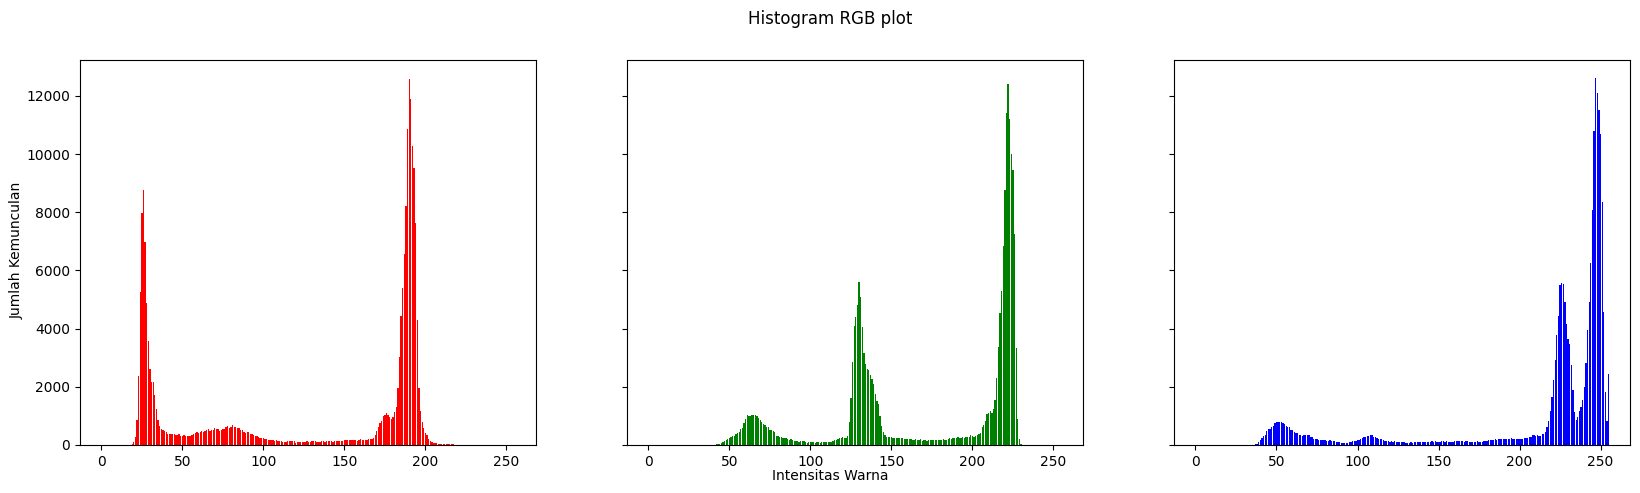

In [39]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/KTM1b.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img [y] [x] [0]] += 1
    green[img[y] [x] [1] ] += 1
    blue[img[y] [x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig. text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig. text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs [0]. bar(names, red, color='red')
axs [1].bar(names, green, color='green')
axs [2].bar(names, blue, color='blue')

# Pertanyaan Praktikum 1
1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [40]:
import cv2 as cv
import numpy as np

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

# tahap 1: lena.jpg
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/lena.jpg', cv.IMREAD_GRAYSCALE)
h_manual = histogram_manual(gray)
h_numpy, _ = np.histogram(gray, bins=256, range=(0,256))
h_cv = cv.calcHist([gray], [0], None, [256], [0,256]).flatten()

print(NIM, '- lena.jpg')
print('selisih manual vs numpy :', np.max(np.abs(h_manual - h_numpy)))
print('selisih manual vs cv    :', np.max(np.abs(h_manual - h_cv)))
print('selisih numpy  vs cv    :', np.max(np.abs(h_numpy - h_cv)))

244107020072 - lena.jpg
selisih manual vs numpy : 0
selisih manual vs cv    : 0.0
selisih numpy  vs cv    : 0.0


In [41]:
# tahap 2: KTM1b.jpg
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
h_manual = histogram_manual(gray)
h_numpy, _ = np.histogram(gray, bins=256, range=(0,256))
h_cv = cv.calcHist([gray], [0], None, [256], [0,256]).flatten()

print(NIM, '- KTM1b.jpg')
print('selisih manual vs numpy :', np.max(np.abs(h_manual - h_numpy)))
print('selisih manual vs cv    :', np.max(np.abs(h_manual - h_cv)))
print('selisih numpy  vs cv    :', np.max(np.abs(h_numpy - h_cv)))

244107020072 - KTM1b.jpg
selisih manual vs numpy : 0
selisih manual vs cv    : 0.0
selisih numpy  vs cv    : 0.0


2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

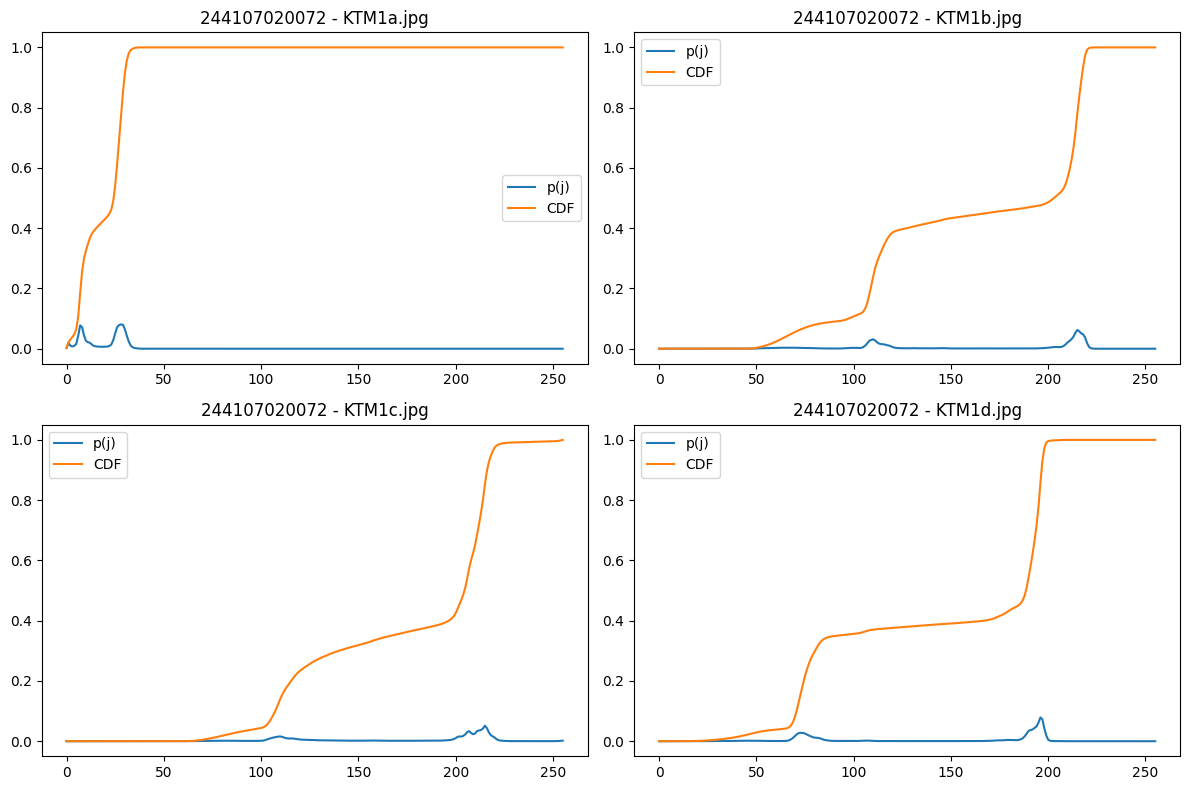

In [42]:
BASE   = '/content/drive/MyDrive/PCVK/Images/244107020072'
files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
fig, axs = plt.subplots(2, 2, figsize=(12,8))
axs = axs.flatten()

for i, f in enumerate(files):
    gray = cv.imread(BASE + '/' + f, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(gray)
    p = h / gray.size
    cdf = np.cumsum(p)
    axs[i].plot(p, label='p(j)')
    axs[i].plot(cdf, label='CDF')
    axs[i].set_title(NIM + ' - ' + f)
    axs[i].legend()

plt.tight_layout()
plt.show()

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

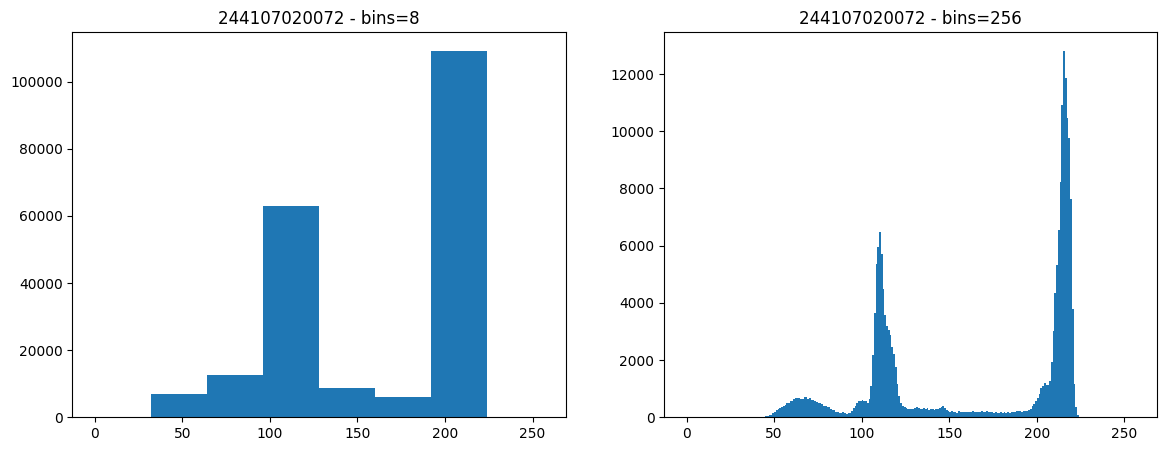

In [43]:
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 2, figsize=(14,5))
axs[0].hist(gray.ravel(), bins=PARAM['bins'], range=(0,256))
axs[0].set_title(NIM + ' - bins=' + str(PARAM['bins']))
axs[1].hist(gray.ravel(), bins=256, range=(0,256))
axs[1].set_title(NIM + ' - bins=256')
plt.show()

# E-2 PERCOBAAN HISTOGRAM EQUALIZATION

### langkah 1

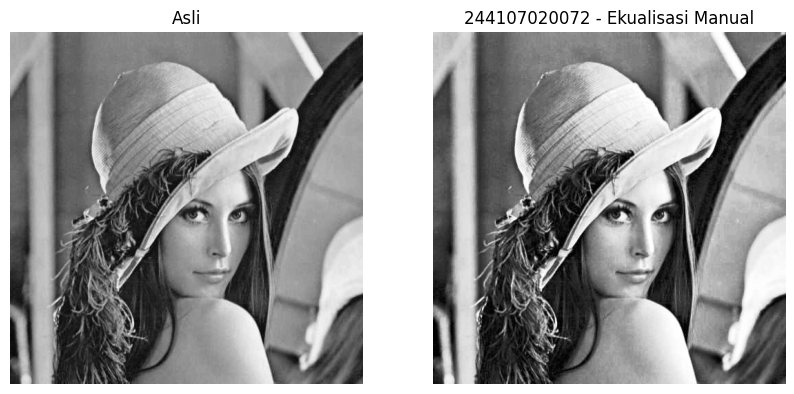

In [44]:
def equalize_manual(gray, L=256):
    h = histogram_manual(gray, L)
    p = h / gray.size
    cdf = np.cumsum(p)
    Ko = np.round(cdf * (L - 1)).astype(np.uint8)
    return Ko[gray]

# tahap 1: lena_lc.jpg
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
eq = equalize_manual(gray)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title('Asli'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(eq, cmap='gray'); plt.title(NIM + ' - Ekualisasi Manual'); plt.axis('off')
plt.show()

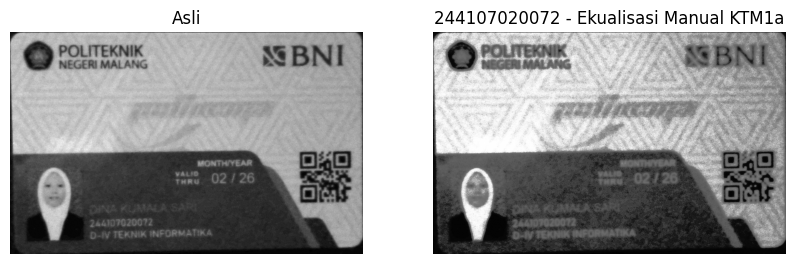

In [45]:
# tahap 2: KTM1a.jpg
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
eq = equalize_manual(gray)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title('Asli'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(eq, cmap='gray'); plt.title(NIM + ' - Ekualisasi Manual KTM1a'); plt.axis('off')
plt.show()

### langkah 2

In [46]:
# tahap 1: lena_lc.jpg
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
eq_manual = equalize_manual(gray)
eq_cv = cv.equalizeHist(gray)
print(NIM, '- lena_lc.jpg, selisih maksimum manual vs equalizeHist:', np.max(np.abs(eq_manual.astype(int) - eq_cv.astype(int))))

244107020072 - lena_lc.jpg, selisih maksimum manual vs equalizeHist: 0


In [47]:
# tahap 2: KTM1a.jpg
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
eq_manual = equalize_manual(gray)
eq_cv = cv.equalizeHist(gray)
print(NIM, '- KTM1a.jpg, selisih maksimum manual vs equalizeHist:', np.max(np.abs(eq_manual.astype(int) - eq_cv.astype(int))))

244107020072 - KTM1a.jpg, selisih maksimum manual vs equalizeHist: 1


### langkah 3

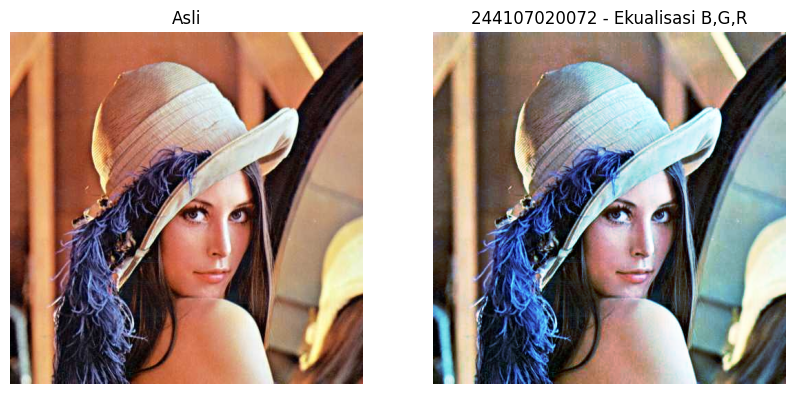

In [48]:
# tahap 1: lena.jpg
berkas = '/content/drive/MyDrive/PCVK/Images/244107020072/lena.jpg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB)); plt.title('Asli'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Ekualisasi B,G,R'); plt.axis('off')
plt.show()

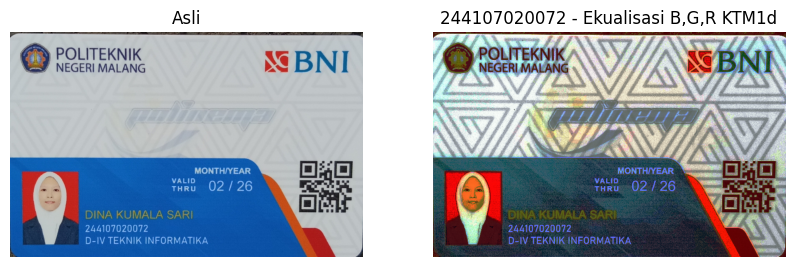

In [49]:
# tahap 2: KTM1d.jpg
berkas ='/content/drive/MyDrive/PCVK/Images/244107020072/KTM1d.jpg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB)); plt.title('Asli'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Ekualisasi B,G,R KTM1d'); plt.axis('off')
plt.show()

### langkah 4

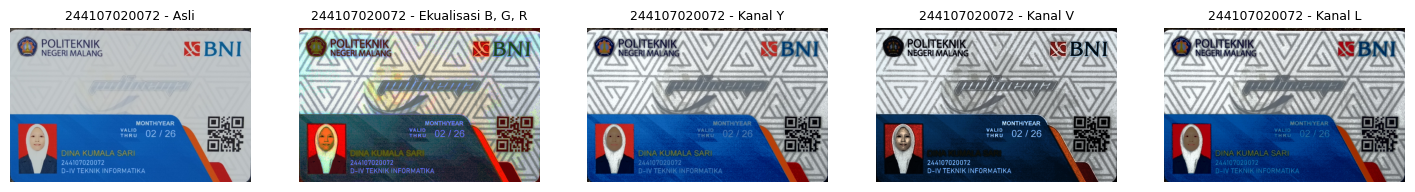

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            147.0
Ekualisasi B, G, R                50.22            131.6
Kanal Y                            1.69            133.1
Kanal V                            2.46            116.3
Kanal L                            4.26            124.7


In [50]:
bgr = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/KTM1d.jpg')

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

# geser ke jalur terpendek
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

# Pertanyaan berdasarkan hasil tabel
1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra Anda?<br>
jawab:<br>
Ekualisasi B, G, R menghasilkan pergeseran Hue yang paling besar. Berdasarkan tabel hasil, nilai pergeseran Hue untuk metode ini pada citra saya adalah 50.22 derajat. <br>

2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra dikembalikan ke ruang warna BGR.<br>
jawab: <br>
Meski hanya kanal terang (Y/V/L) yang diekualisasi, hasilnya tetap dikonversi balik ke BGR dalam bentuk desimal lalu dibulatkan ke integer 8-bit dengan clipping (0-255). Pembulatan dan clipping pada kanal R, G, B secara terpisah ini menggeser proporsi RGB, sehingga Hue ikut bergeser dan tidak lagi persis nol.<br>

3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.<br>
jawab:<br>
Kanal Y paling sesuai karena pergeseran Hue-nya paling kecil (1.69° vs V 2.46° dan L 4.26°). Ini terlihat dari warna kulit/wajah atau latar (misal warna KTM) yang tetap natural, tidak over-saturated seperti pada hasil V atau L.<br>

4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil ekualisasi biasa.<br>
jawab:<br>
Perbandingan Kanal Y: ekualisasi biasa menghasilkan pergeseran Hue 1.69° dengan rerata kecerahan 133.1, sedangkan CLAHE (clipLimit=2.0, tileGridSize=(2,2)) menurunkan pergeseran Hue jadi 0.02° dengan rerata kecerahan naik ke 151.0. Kesimpulannya, CLAHE lebih baik mempertahankan warna asli sekaligus meningkatkan kecerahan tanpa over-enhancement.<br>

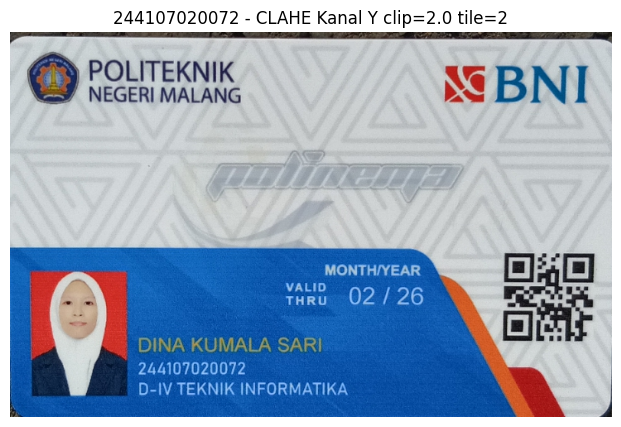

Ekualisasi biasa (Kanal Y) geser Hue: 1.69, kecerahan: 133.1
CLAHE (Kanal Y) geser Hue: 0.02, kecerahan: 151.0


In [51]:
# Kode jawaban no 4
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
clahe_y = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

plt.figure(figsize=(8,5))
plt.imshow(cv.cvtColor(clahe_y, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - CLAHE Kanal Y clip=' + str(PARAM['clip']) + ' tile=' + str(PARAM['tile']))
plt.axis('off')
plt.show()

print('Ekualisasi biasa (Kanal Y) geser Hue: %.2f, kecerahan: %.1f' %
      (geser_hue(bgr, he_y) * 2, cv.cvtColor(he_y, cv.COLOR_BGR2GRAY).mean()))
print('CLAHE (Kanal Y) geser Hue: %.2f, kecerahan: %.1f' %
      (geser_hue(bgr, clahe_y) * 2, cv.cvtColor(clahe_y, cv.COLOR_BGR2GRAY).mean()))

# PERTANYAAN PRAKTIKUM E2
1. Ekualisasi global pada citra KTM Anda
a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.
b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.
c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.

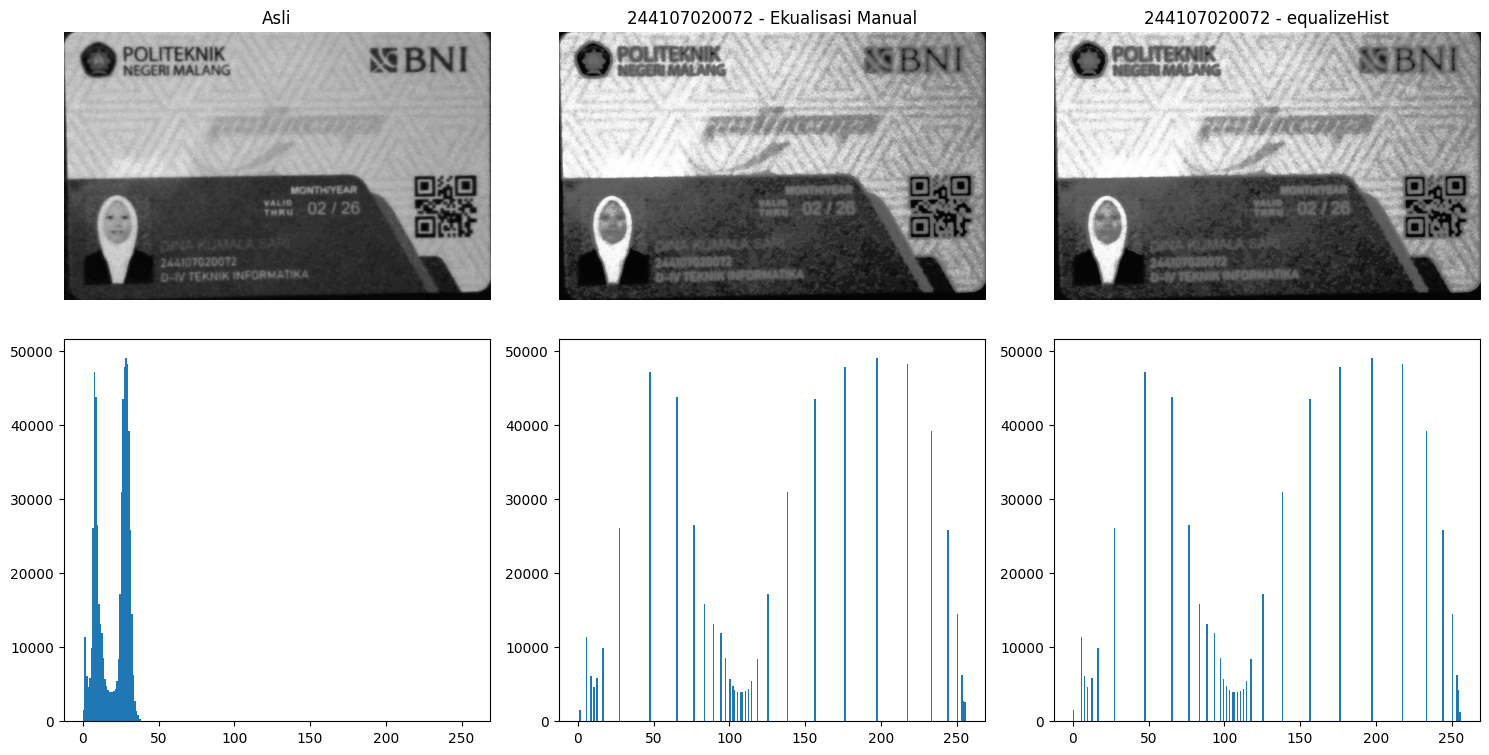

244107020072 - PSNR asli vs ekualisasi manual : 5.74014172299324
244107020072 - PSNR asli vs equalizeHist      : 5.743783934683426


In [52]:
def psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
eq_manual = equalize_manual(gray)
eq_cv = cv.equalizeHist(gray)

fig, axs = plt.subplots(2, 3, figsize=(15,8))
axs[0,0].imshow(gray, cmap='gray'); axs[0,0].set_title('Asli'); axs[0,0].axis('off')
axs[0,1].imshow(eq_manual, cmap='gray'); axs[0,1].set_title(NIM + ' - Ekualisasi Manual'); axs[0,1].axis('off')
axs[0,2].imshow(eq_cv, cmap='gray'); axs[0,2].set_title(NIM + ' - equalizeHist'); axs[0,2].axis('off')
axs[1,0].hist(gray.ravel(), bins=256, range=(0,256))
axs[1,1].hist(eq_manual.ravel(), bins=256, range=(0,256))
axs[1,2].hist(eq_cv.ravel(), bins=256, range=(0,256))
plt.tight_layout()
plt.show()

print(NIM, '- PSNR asli vs ekualisasi manual :', psnr(gray, eq_manual))
print(NIM, '- PSNR asli vs equalizeHist      :', psnr(gray, eq_cv))

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda
a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?
b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.

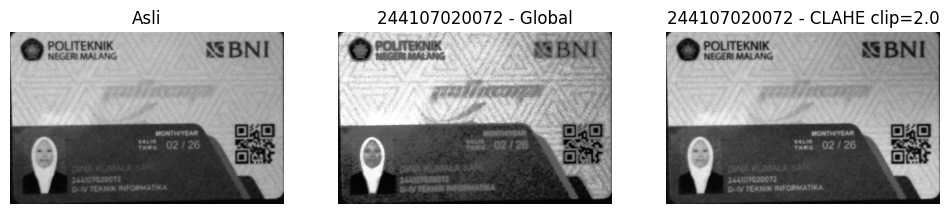

In [53]:
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
eq_global = cv.equalizeHist(gray)

clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
eq_clahe = clahe.apply(gray)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title('Asli'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(eq_global, cmap='gray'); plt.title(NIM + ' - Global'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(eq_clahe, cmap='gray'); plt.title(NIM + ' - CLAHE clip=' + str(PARAM['clip'])); plt.axis('off')
plt.show()

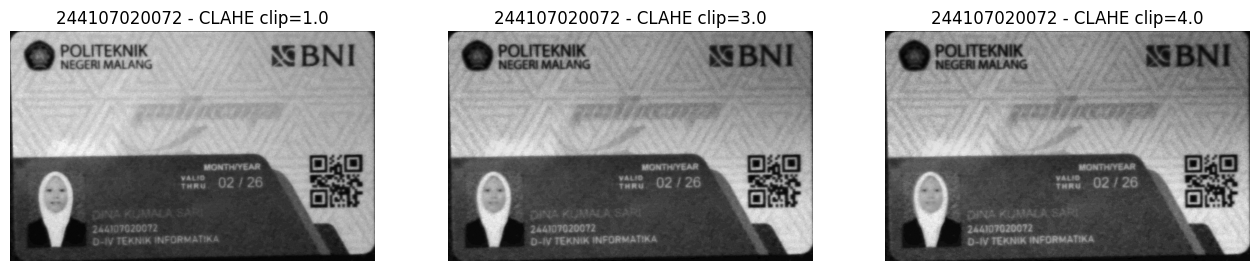

In [54]:
# eksplorasi 3 nilai clipLimit lain di sekitar PARAM['clip'] (2.0)
clip_values = [1.0, 3.0, 4.0]

plt.figure(figsize=(16,5))
for i, cl in enumerate(clip_values, 1):
    clahe_i = cv.createCLAHE(clipLimit=cl, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe_i.apply(gray)
    plt.subplot(1, 3, i)
    plt.imshow(hasil, cmap='gray')
    plt.title(NIM + ' - CLAHE clip=' + str(cl))
    plt.axis('off')
plt.show()

# E-3 TUGAS PRAKTIKUM DITHERING

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].

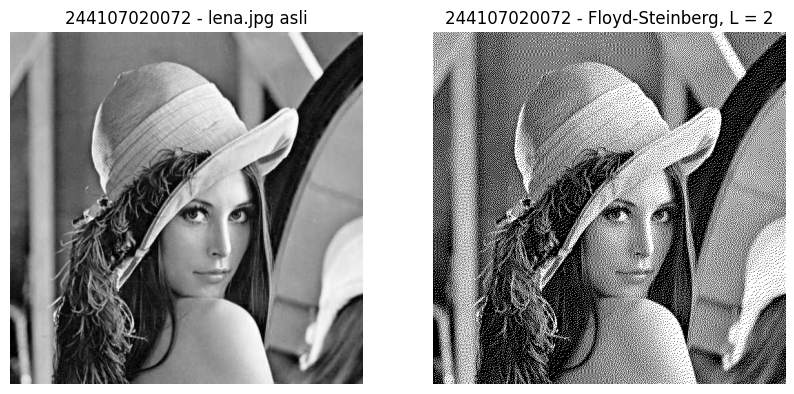

In [55]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                    img[y,   x+1] += error * 7 / 16
            if x > 0 and y+1 < H:            img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                    img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y+1 < H:        img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

# tahap 1: lena.jpg
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/lena.jpg', cv.IMREAD_GRAYSCALE)
dither = floyd_steinberg(gray, L=2)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title(NIM + ' - lena.jpg asli'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(dither, cmap='gray'); plt.title(NIM + ' - Floyd-Steinberg, L = 2'); plt.axis('off')
plt.show()

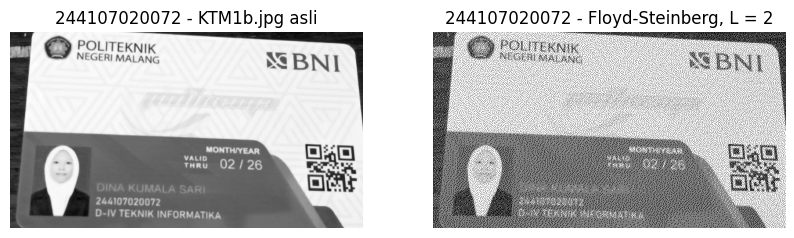

In [56]:
# tahap 2: KTM1b.jpg dengan PARAM['L']
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
dither = floyd_steinberg(gray, L=PARAM['L'])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title(NIM + ' - KTM1b.jpg asli'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(dither, cmap='gray'); plt.title(NIM + ' - Floyd-Steinberg, L = ' + str(PARAM['L'])); plt.axis('off')
plt.show()

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.

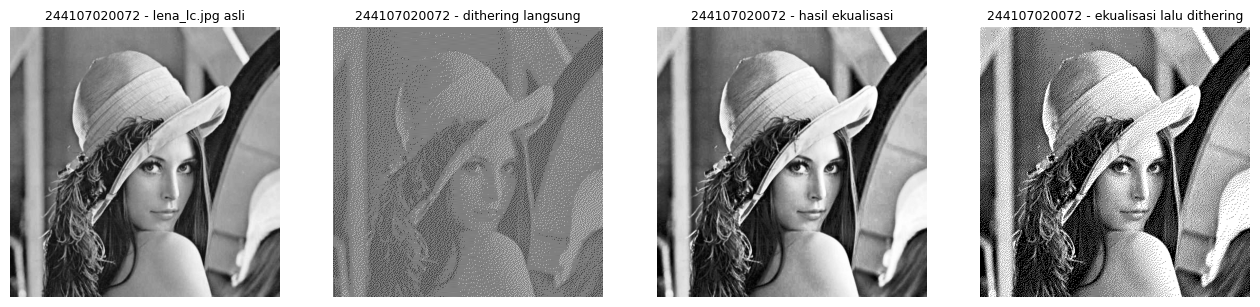

In [57]:
# tahap 1: lena_lc.jpg
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
dither_langsung = floyd_steinberg(gray, L=2)
eq = cv.equalizeHist(gray)
dither_setelah_eq = floyd_steinberg(eq, L=2)

judul = [NIM + ' - lena_lc.jpg asli', NIM + ' - dithering langsung',
         NIM + ' - hasil ekualisasi', NIM + ' - ekualisasi lalu dithering']
citra = [gray, dither_langsung, eq, dither_setelah_eq]

plt.figure(figsize=(16,4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 4, i)
    plt.imshow(c, cmap='gray')
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.show()

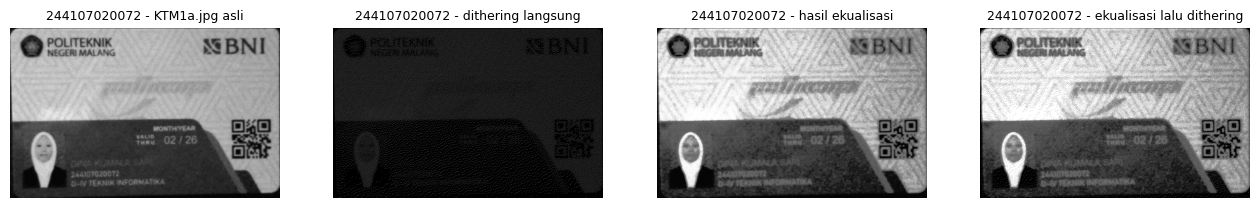

In [58]:
# tahap 2: KTM1a.jpg dengan PARAM['L']
gray = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
dither_langsung = floyd_steinberg(gray, L=PARAM['L'])
eq = cv.equalizeHist(gray)
dither_setelah_eq = floyd_steinberg(eq, L=PARAM['L'])

judul = [NIM + ' - KTM1a.jpg asli', NIM + ' - dithering langsung',
         NIM + ' - hasil ekualisasi', NIM + ' - ekualisasi lalu dithering']
citra = [gray, dither_langsung, eq, dither_setelah_eq]

plt.figure(figsize=(16,4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 4, i)
    plt.imshow(c, cmap='gray')
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.show()